# Part 3 — Integrated Best Combination

## Purpose

This notebook composes the validated choices without introducing a new optimizer or a new broad search:

1. standard Adam with the Part 2 hyperparameters,
2. the Part 3 regularization combination,
3. the Part 1 best RO method on the same final-layer parameter cap,
4. an RO fine-tuning budget no larger than 10% of Part 1.

It ends with a quantitative hypothesis resolution and a practical decision rule for Covertype.

In [16]:
from pathlib import Path
from copy import deepcopy
import os, math, platform, random, time, json, warnings
from dataclasses import dataclass, asdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_recall_fscore_support,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# reproducibility and run modes
BASE_SEED = 42
FULL_SEEDS = [42, 202, 7641]
SMOKE_TEST = os.getenv("OL_SMOKE_TEST", "0") == "1"
QUICK_MODE = os.getenv("OL_QUICK_MODE", "0") == "1" or SMOKE_TEST
SEEDS = [42] if QUICK_MODE else FULL_SEEDS
DEVICE = torch.device(os.getenv("OL_DEVICE", "cpu"))
TORCH_THREADS = max(1, min(4, os.cpu_count() or 1))
torch.set_num_threads(TORCH_THREADS)

def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

set_all_seeds(BASE_SEED)

# input directories
DATA_PATH = Path("output_data/eda_dataset_original/dataset_stratified.csv")
DATA_PATH_TEST = Path("output_data/eda_dataset_original/dataset_remainder.csv")
RAW_DATA_PATH = Path("dataset_covertype/covtype.data")
TARGET_COL = "Cover_Type"

# Values are fixed by the SL Report notebook.
SL_ARCHITECTURE = (64, 64)
SL_LEARNING_RATE = 0.10
SL_BATCH_SIZE = 512
SL_WEIGHT_DECAY = 1e-4
SL_MAX_EPOCHS = 70
SL_PATIENCE = 10

# Exact SL-notebook reference result from the output.
SL_REFERENCE = {
    "method": "SL PyTorch SGD-only reference",
    "architecture": str(SL_ARCHITECTURE),
    "parameter_count": 8135,
    "learning_rate": 0.10,
    "batch_size": 512,
    "weight_decay": 1e-4,
    "best_epoch": 26,
    "epochs_run": 36,
    "test_accuracy": 0.6400986075,
    "test_macro_f1": 0.5526402660,
    "test_balanced_accuracy": 0.7019769460,
    "fit_time_sec_on_original_hardware": 2.675669709,
}

### 1. Data loading: Exact SL report split and processing

In [17]:
df_source = pd.read_csv(DATA_PATH)
df_test_external = pd.read_csv(DATA_PATH_TEST)

assert TARGET_COL in df_source.columns and TARGET_COL in df_test_external.columns
feature_cols = [c for c in df_source.columns if c != TARGET_COL]
assert len(feature_cols) == 54, f"Expected 54 features, found {len(feature_cols)}"
assert list(df_test_external.columns) == list(df_source.columns), "Development/test columns differ."
assert len(df_source) == 20_000, f"Expected 20,000 sampled rows, found {len(df_source)}"
assert len(df_test_external) == 561_012, f"Expected 561,012 remainder rows, found {len(df_test_external)}"
assert df_source.isna().sum().sum() == 0 and df_test_external.isna().sum().sum() == 0

X_source_df = df_source[feature_cols].copy()
y_source_raw = df_source[TARGET_COL].copy()
X_test_df = df_test_external[feature_cols].copy()
y_test_raw = df_test_external[TARGET_COL].copy()

### 2. Reproducing the SL-report notebook stable class mapping

In [18]:
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_source_raw, y_test_raw], ignore_index=True))
class_labels = label_encoder.classes_
classes = np.arange(len(class_labels))
class_names = [f"Cover_Type_{c}" for c in class_labels]

X_train_df, X_val_df, y_train_raw, y_val_raw = train_test_split(
    X_source_df,
    y_source_raw,
    test_size=0.20,
    stratify=y_source_raw,
    random_state=BASE_SEED,
)

y_train = label_encoder.transform(y_train_raw).astype(np.int64)
y_val = label_encoder.transform(y_val_raw).astype(np.int64)
y_test = label_encoder.transform(y_test_raw).astype(np.int64)

### 3. Leakage safety: fittin learned scalling only on 16K rows training split

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

class_weights_np = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
).astype(np.float32)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=DEVICE)

steps_per_epoch = math.ceil(len(y_train) / SL_BATCH_SIZE)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "source": [DATA_PATH.name, DATA_PATH.name, DATA_PATH_TEST.name],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "purpose": ["fit", "selection only", "final locked evaluation only"],
})
display(split_summary)

print({
    "device": str(DEVICE),
    "torch": torch.__version__,
    "python": platform.python_version(),
    "cpu": platform.processor() or platform.machine(),
    "torch_threads": TORCH_THREADS,
    "quick_mode": QUICK_MODE,
    "seeds": SEEDS,
    "steps_per_epoch": steps_per_epoch,
})


,split,source,rows,purpose
0,train,dataset_stratified.csv,16000,fit
1,validation,dataset_stratified.csv,4000,selection only
2,test,dataset_remainder.csv,561012,final locked evaluation only


{'device': 'cpu', 'torch': '2.5.1', 'python': '3.11.15', 'cpu': 'x86_64', 'torch_threads': 4, 'quick_mode': False, 'seeds': [42, 202, 7641], 'steps_per_epoch': 32}


### 4. Fixing PyTorch backbone with permitted dropout regularizaiton

In [20]:
class CompactMLP(nn.Module):
    """The exact 54 -> 64 -> 64 -> 7 SL backbone.

    Dropout modules are inserted only when Part 3/4 explicitly studies regularization;
    all Linear layer dimensions and ReLU placements remain unchanged.
    """
    def __init__(self, input_dim=54, hidden_layers=SL_ARCHITECTURE, output_dim=7, dropout=0.0):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.extend([nn.Linear(prev, width), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)
        self.dropout = float(dropout)

    def forward(self, x):
        return self.net(x)


def count_parameters(model, trainable_only=True):
    params = (p for p in model.parameters() if (p.requires_grad or not trainable_only))
    return sum(p.numel() for p in params)


_base_model_check = CompactMLP().to(DEVICE)
assert count_parameters(_base_model_check) == 8135
print(f"Backbone parameter count confirmed: {count_parameters(_base_model_check):,}")
del _base_model_check

Backbone parameter count confirmed: 8,135


### 5. Metrics and Evaluation

In [21]:
def metric_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
    }


def make_criterion(label_smoothing=0.0):
    return nn.CrossEntropyLoss(weight=class_weights_t, label_smoothing=float(label_smoothing))


def evaluate_tensor(model, X_t, y_t, criterion):
    model.eval()
    with torch.inference_mode():
        logits = model(X_t)
        loss = float(criterion(logits, y_t).item())
        pred = logits.argmax(dim=1).cpu().numpy()
    out = metric_dict(y_t.cpu().numpy(), pred)
    out["loss"] = loss
    return out, pred


def full_report(y_true, y_pred):
    report = pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, target_names=class_names,
        output_dict=True, zero_division=0,
    )).T
    cm = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=classes),
        index=class_names, columns=class_names,
    )
    return report, cm


def clone_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def load_state(model, state):
    model.load_state_dict({k: v.to(DEVICE) for k, v in state.items()})

### 6. Adam without bias correction

In [22]:
class AdamNoBiasCorrection(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        if lr <= 0:
            raise ValueError("lr must be positive")
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None if closure is None else closure()
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if g.is_sparse:
                    raise RuntimeError("Sparse gradients are not supported.")
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["exp_avg_sq"] = torch.zeros_like(p)
                state["step"] += 1
                m, v = state["exp_avg"], state["exp_avg_sq"]
                m.mul_(beta1).add_(g, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(g, g, value=1 - beta2)
                p.addcdiv_(m, v.sqrt().add_(group["eps"]), value=-group["lr"])
        return loss


def build_optimizer(name, model, lr, beta1=0.9, beta2=0.999, weight_decay=0.0):
    params = [p for p in model.parameters() if p.requires_grad]
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.0, weight_decay=weight_decay)
    if name == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=False, weight_decay=weight_decay)
    if name == "sgd_nesterov":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    if name == "adam_no_bias_correction":
        return AdamNoBiasCorrection(params, lr=lr, betas=(beta1, beta2))
    if name == "adam_beta1_zero":
        return torch.optim.Adam(params, lr=lr, betas=(0.0, beta2), weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, betas=(beta1, beta2), weight_decay=weight_decay)
    raise ValueError(f"Unknown optimizer: {name}")

### 7. Controlled-budget trainer

In [23]:
@dataclass
class TrainConfig:
    optimizer_name: str
    lr: float
    max_updates: int
    batch_size: int = SL_BATCH_SIZE
    beta1: float = 0.9
    beta2: float = 0.999
    weight_decay: float = 0.0
    dropout: float = 0.0
    label_smoothing: float = 0.0
    input_noise_std: float = 0.0
    early_stopping_patience: int | None = None
    selection_metric: str = "val_loss"
    restore_best: bool = True
    eval_every_updates: int = steps_per_epoch


def train_controlled(config: TrainConfig, seed: int, initial_state=None):
    set_all_seeds(seed)
    model = CompactMLP(dropout=config.dropout).to(DEVICE)
    if initial_state is not None:
        load_state(model, initial_state)
    criterion = make_criterion(config.label_smoothing)
    optimizer = build_optimizer(
        config.optimizer_name, model, config.lr, config.beta1, config.beta2, config.weight_decay
    )

    n = len(y_train)
    update = 0
    history = []
    start_time = time.perf_counter()
    best_score = np.inf if config.selection_metric == "val_loss" else -np.inf
    best_state = clone_state(model)
    best_update = 0
    stale_evals = 0
    stopped_early = False
    interval_loss_sum = 0.0
    interval_examples = 0

    while update < config.max_updates:
        model.train()
        permutation = torch.randperm(n, device=DEVICE)
        for batch_start in range(0, n, config.batch_size):
            if update >= config.max_updates:
                break
            idx = permutation[batch_start: batch_start + config.batch_size]
            xb = X_train_t[idx]
            if config.input_noise_std > 0:
                xb = xb + torch.randn_like(xb) * config.input_noise_std
            yb = y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            update += 1
            interval_loss_sum += float(loss.item()) * len(idx)
            interval_examples += len(idx)

            should_eval = (
                update == 1
                or update % config.eval_every_updates == 0
                or update == config.max_updates
            )
            if not should_eval:
                continue

            train_metrics, _ = evaluate_tensor(model, X_train_t, y_train_t, criterion)
            val_metrics, _ = evaluate_tensor(model, X_val_t, y_val_t, criterion)
            elapsed = time.perf_counter() - start_time
            row = {
                "seed": seed,
                "update": update,
                "gradient_evaluations": update,
                "optimizer_updates": update,
                "examples_seen": update * config.batch_size,
                "wall_time_sec": elapsed,
                "interval_train_loss": interval_loss_sum / max(1, interval_examples),
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
            }
            history.append(row)
            interval_loss_sum = 0.0
            interval_examples = 0

            score = val_metrics[config.selection_metric.replace("val_", "")]
            improved = score < best_score - 1e-6 if config.selection_metric == "val_loss" else score > best_score + 1e-6
            if improved:
                best_score = score
                best_state = clone_state(model)
                best_update = update
                stale_evals = 0
            else:
                stale_evals += 1

            if config.early_stopping_patience is not None and stale_evals >= config.early_stopping_patience:
                stopped_early = True
                break
        if stopped_early:
            break

    total_time = time.perf_counter() - start_time
    final_state = clone_state(model)
    if config.restore_best:
        load_state(model, best_state)
    selected_metrics, selected_pred = evaluate_tensor(model, X_val_t, y_val_t, criterion)

    return {
        "model": model,
        "config": asdict(config),
        "seed": seed,
        "history": pd.DataFrame(history),
        "best_state": best_state,
        "final_state": final_state,
        "best_update": int(best_update),
        "updates_run": int(update),
        "gradient_evaluations": int(update),
        "wall_time_sec": float(total_time),
        "stopped_early": stopped_early,
        "selected_val_metrics": selected_metrics,
        "selected_val_pred": selected_pred,
        "parameter_count": count_parameters(model),
    }


def evaluate_test_locked(run, method_name):
    """Call only after all validation-based choices have been locked."""
    criterion = make_criterion(run["config"].get("label_smoothing", 0.0))
    metrics, pred = evaluate_tensor(run["model"], X_test_t, y_test_t, criterion)
    report, cm = full_report(y_test, pred)
    row = {
        "method": method_name,
        "seed": run["seed"],
        "best_val_loss": run["selected_val_metrics"]["loss"],
        "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "test_accuracy": metrics["accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "wall_time_sec": run["wall_time_sec"],
        "gradient_evaluations": run["gradient_evaluations"],
        "function_evaluations": 0,
        "notes": json.dumps(run["config"], sort_keys=True),
    }
    return row, report, cm, pred


def representative_seed(summary_df, metric="best_val_macro_f1"):
    med = summary_df[metric].median()
    idx = (summary_df[metric] - med).abs().idxmin()
    return int(summary_df.loc[idx, "seed"])


def save_json(path, obj):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, sort_keys=True)


def plot_confusion_matrix(cm_df, title, path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_df.values, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_xticks(range(len(class_labels)), class_labels)
    ax.set_yticks(range(len(class_labels)), class_labels)
    fig.colorbar(im, ax=ax)
    threshold = cm_df.values.max() * 0.55
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            ax.text(j, i, str(cm_df.iat[i, j]), ha="center", va="center",
                    fontsize=7, color="white" if cm_df.iat[i, j] > threshold else "black")
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

### 8. Randomized optimization helpers

In [24]:
def get_linear_modules(model):
    return [m for m in model.modules() if isinstance(m, nn.Linear)]


def freeze_for_ro(model, final_linear_layers=1):
    for p in model.parameters():
        p.requires_grad = False
    linear_layers = get_linear_modules(model)
    selected = linear_layers[-final_linear_layers:]
    for layer in selected:
        for p in layer.parameters():
            p.requires_grad = True
    trainable = [p for p in model.parameters() if p.requires_grad]
    trainable_count = sum(p.numel() for p in trainable)
    if trainable_count > 50_000:
        raise ValueError(f"RO trainable parameter count {trainable_count:,} exceeds 50,000.")
    return trainable, trainable_count


def vector_from_params(params):
    return torch.cat([p.detach().flatten().cpu() for p in params]).numpy().astype(np.float32)


def vector_to_params(vector, params):
    vector_t = torch.tensor(vector, dtype=torch.float32, device=DEVICE)
    offset = 0
    with torch.no_grad():
        for p in params:
            n = p.numel()
            p.copy_(vector_t[offset:offset+n].view_as(p))
            offset += n
    assert offset == len(vector)


def make_fixed_ro_validation_subset(size=2000, seed=BASE_SEED):
    size = min(size, len(y_val))
    idx, _ = train_test_split(
        np.arange(len(y_val)), train_size=size, stratify=y_val, random_state=seed
    )
    idx_t = torch.tensor(np.sort(idx), dtype=torch.long, device=DEVICE)
    return X_val_t[idx_t], y_val_t[idx_t], idx


RO_X_t, RO_y_t, RO_indices = make_fixed_ro_validation_subset(1000 if QUICK_MODE else 2000)


def make_ro_objective(model, params, criterion):
    calls = {"count": 0}
    def objective(vector):
        vector_to_params(vector, params)
        model.eval()
        with torch.inference_mode():
            value = float(criterion(model(RO_X_t), RO_y_t).item())
        calls["count"] += 1
        return value
    return objective, calls


def rhc_optimize(objective, x0, budget, seed, restart_patience=50,
                 initial_step=0.025, step_decay=0.995, min_step=0.002,
                 restart_scale=0.05):
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    current = x0.copy()
    current_obj = objective(current)
    best, best_obj = current.copy(), current_obj
    history = [{"function_evaluation": 1, "current_objective": current_obj,
                "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                "accepted": True, "restart": False}]
    no_improve = 0
    restarts = 0
    while len(history) < budget:
        fe = len(history) + 1
        step = max(min_step, initial_step * (step_decay ** (fe - 1)))
        is_restart = no_improve >= restart_patience
        if is_restart:
            candidate = x0 + rng.normal(0, restart_scale, size=x0.shape).astype(np.float32)
            restarts += 1
            no_improve = 0
        else:
            candidate = current + rng.normal(0, step, size=x0.shape).astype(np.float32)
        candidate_obj = objective(candidate)
        accepted = is_restart or candidate_obj < current_obj
        if accepted:
            current, current_obj = candidate, candidate_obj
        if candidate_obj < best_obj:
            best, best_obj = candidate.copy(), candidate_obj
            no_improve = 0
        else:
            no_improve += 1
        history.append({"function_evaluation": fe, "current_objective": current_obj,
                        "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                        "accepted": accepted, "restart": is_restart, "step_scale": step})
    return best, best_obj, pd.DataFrame(history), {"restarts": restarts}


def sa_optimize(objective, x0, budget, seed, initial_temperature=0.10,
                decay=0.985, initial_step=0.025, min_step=0.0015):
    rng = np.random.default_rng(seed)
    start = time.perf_counter()
    current = x0.copy()
    current_obj = objective(current)
    best, best_obj = current.copy(), current_obj
    history = [{"function_evaluation": 1, "current_objective": current_obj,
                "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                "accepted": True, "temperature": initial_temperature,
                "step_scale": initial_step}]
    accepted_count = 1
    while len(history) < budget:
        fe = len(history) + 1
        temperature = initial_temperature * (decay ** (fe - 1))
        step = max(min_step, initial_step * math.sqrt(max(temperature, 1e-12) / initial_temperature))
        candidate = current + rng.normal(0, step, size=x0.shape).astype(np.float32)
        candidate_obj = objective(candidate)
        delta = candidate_obj - current_obj
        accept = delta <= 0 or rng.random() < math.exp(-delta / max(temperature, 1e-12))
        if accept:
            current, current_obj = candidate, candidate_obj
            accepted_count += 1
        if candidate_obj < best_obj:
            best, best_obj = candidate.copy(), candidate_obj
        history.append({"function_evaluation": fe, "current_objective": current_obj,
                        "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                        "accepted": accept, "temperature": temperature, "step_scale": step})
    return best, best_obj, pd.DataFrame(history), {"acceptance_rate": accepted_count / budget}


def ga_optimize(objective, x0, budget, seed, population_size=20,
                tournament_size=3, crossover_blend=0.25, mutation_rate=0.05,
                mutation_scale=0.02, elite_count=2):
    rng = np.random.default_rng(seed)
    population_size = min(population_size, budget)
    elite_count = min(elite_count, population_size - 1)
    start = time.perf_counter()
    population = [x0.copy()]
    population += [x0 + rng.normal(0, 0.04, size=x0.shape).astype(np.float32)
                   for _ in range(population_size - 1)]
    scores, history = [], []
    best, best_obj = x0.copy(), np.inf
    fe = 0
    for individual in population:
        if fe >= budget:
            break
        score = objective(individual); fe += 1; scores.append(score)
        if score < best_obj:
            best, best_obj = individual.copy(), score
        history.append({"function_evaluation": fe, "current_objective": score,
                        "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                        "generation": 0})
    population = population[:len(scores)]
    scores = np.asarray(scores)
    generation = 0

    def tournament_pick():
        ids = rng.integers(0, len(population), size=min(tournament_size, len(population)))
        return population[int(ids[np.argmin(scores[ids])])]

    while fe < budget:
        generation += 1
        order = np.argsort(scores)
        next_population = [population[i].copy() for i in order[:elite_count]]
        next_scores = [float(scores[i]) for i in order[:elite_count]]
        while len(next_population) < population_size and fe < budget:
            p1, p2 = tournament_pick(), tournament_pick()
            alpha = rng.uniform(-crossover_blend, 1 + crossover_blend, size=x0.shape).astype(np.float32)
            child = alpha * p1 + (1 - alpha) * p2
            mask = rng.random(x0.shape) < mutation_rate
            if mask.any():
                child[mask] += rng.normal(0, mutation_scale, size=int(mask.sum())).astype(np.float32)
            score = objective(child); fe += 1
            next_population.append(child.astype(np.float32)); next_scores.append(score)
            if score < best_obj:
                best, best_obj = child.copy(), score
            history.append({"function_evaluation": fe, "current_objective": score,
                            "best_objective": best_obj, "wall_time_sec": time.perf_counter()-start,
                            "generation": generation})
        population, scores = next_population, np.asarray(next_scores)
    return best, best_obj, pd.DataFrame(history), {"generations": generation}


def run_ro_algorithm(name, objective, x0, budget, seed, settings=None):
    settings = dict(settings or {})
    if name == "RHC":
        return rhc_optimize(objective, x0, budget, seed, **settings)
    if name == "SA":
        return sa_optimize(objective, x0, budget, seed, **settings)
    if name == "GA":
        return ga_optimize(objective, x0, budget, seed, **settings)
    raise ValueError(name)

### 9. Load locked configurations and enforce Part 4 constraints

In [25]:
PART = "ol_part4"
FIG_DIR = Path("output_figures") / PART
RESULTS_DIR = Path("output_results") / PART
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def load_or_fallback(path, fallback):
    p = Path(path)
    if p.exists():
        print("Loaded", p)
        return json.loads(p.read_text())
    print("Missing", p, "-- using documented fallback.")
    return fallback

ADAM_CFG = load_or_fallback("output_results/ol_part2/best_adam_config.json",
    {"optimizer_name": "adam", "lr": 1e-3, "beta1": .9, "beta2": .999,
     "batch_size": SL_BATCH_SIZE, "main_update_budget": 1600})
REG_CFG = load_or_fallback("output_results/ol_part3/best_regularization_config.json",
    {"name": "fallback_wd_dropout", "weight_decay": 1e-4, "dropout": .2,
     "label_smoothing": .05, "input_noise_std": .01, "early_stopping_patience": 5,
     "max_updates": int(ADAM_CFG.get("main_update_budget", 1600))})
RO_CFG = load_or_fallback("output_results/ol_part1/best_ro_config.json",
    {"algorithm": "SA", "settings": {"initial_temperature": .10, "decay": .985,
     "initial_step": .025, "min_step": .0015}, "part1_function_evaluation_budget": 300,
     "final_linear_layers": 1, "trainable_parameter_count": 455})

MAIN_UPDATES = 160 if QUICK_MODE else int(REG_CFG.get("max_updates", ADAM_CFG.get("main_update_budget", 1600)))
PART1_FE_BUDGET = int(RO_CFG["part1_function_evaluation_budget"])
PART4_RO_BUDGET = max(4, int(math.floor(0.10 * PART1_FE_BUDGET)))
if QUICK_MODE:
    PART4_RO_BUDGET = min(PART4_RO_BUDGET, 8)
assert PART4_RO_BUDGET <= 0.10 * PART1_FE_BUDGET + 1e-9

print({"adam": ADAM_CFG, "regularization": REG_CFG, "ro": RO_CFG,
       "main_updates": MAIN_UPDATES, "part4_ro_budget": PART4_RO_BUDGET})

Loaded output_results/ol_part2/best_adam_config.json
Loaded output_results/ol_part3/best_regularization_config.json
Loaded output_results/ol_part1/best_ro_config.json
{'adam': {'batch_size': 512, 'beta1': 0.9, 'beta2': 0.99, 'lr': 0.003, 'main_update_budget': 1600, 'optimizer_name': 'adam', 'selection_rule': 'coarse validation heatmaps; lowest validation loss with Macro-F1 tie-break'}, 'regularization': {'batch_size': 512, 'best_single_regularizer': 'L2 weight decay', 'best_single_value': 0.0001, 'dropout': 0.1, 'early_stopping_patience': None, 'input_noise_std': 0.0, 'label_smoothing': 0.0, 'max_updates': 1600, 'name': 'wd+dropout', 'optimizer': {'beta1': 0.9, 'beta2': 0.99, 'lr': 0.003, 'name': 'adam'}, 'selection_rule': 'median validation Macro-F1; validation loss tie-break', 'weight_decay': 0.0001}, 'ro': {'algorithm': 'RHC', 'final_linear_layers': 1, 'part1_function_evaluation_budget': 300, 'selection_rule': 'lowest median full-validation loss; Macro-F1 tie-break', 'settings': {'i

### 10. At most five small interaction trials

In [26]:
base_dropout = float(REG_CFG.get("dropout", 0.0))
dropout_trials = sorted(set([max(0.0, base_dropout - 0.05), base_dropout, min(0.5, base_dropout + 0.05)]))
assert len(dropout_trials) <= 5


def integrated_train_config(dropout):
    return TrainConfig(
        optimizer_name="adam", lr=float(ADAM_CFG["lr"]), max_updates=MAIN_UPDATES,
        beta1=float(ADAM_CFG["beta1"]), beta2=float(ADAM_CFG["beta2"]),
        weight_decay=float(REG_CFG.get("weight_decay", 0.0)),
        dropout=float(dropout),
        label_smoothing=float(REG_CFG.get("label_smoothing", 0.0)),
        input_noise_std=float(REG_CFG.get("input_noise_std", 0.0)),
        early_stopping_patience=(
            int(REG_CFG["early_stopping_patience"])
            if REG_CFG.get("early_stopping_patience") is not None else None
        ),
        selection_metric="val_loss", restore_best=True,
    )

interaction_rows = []
for p in dropout_trials:
    run = train_controlled(integrated_train_config(p), BASE_SEED)
    interaction_rows.append({"dropout": p,
                             "best_val_loss": run["selected_val_metrics"]["loss"],
                             "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
                             "best_val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"]})
interaction_table = pd.DataFrame(interaction_rows).sort_values(["best_val_macro_f1", "best_val_loss"], ascending=[False, True])
LOCKED_DROPOUT = float(interaction_table.iloc[0].dropout)
display(interaction_table)
print("Locked Part 4 dropout:", LOCKED_DROPOUT)

,dropout,best_val_loss,best_val_macro_f1,best_val_balanced_accuracy
2,0.15,0.577985,0.599586,0.769079
0,0.05,0.587301,0.594000,0.777206
1,0.10,0.579184,0.549942,0.762616


Locked Part 4 dropout: 0.15000000000000002


### 11. Train the integrated Adam + regularization recipe across seeds

In [27]:
integrated_runs, integrated_rows = {}, []
for seed in SEEDS:
    run = train_controlled(integrated_train_config(LOCKED_DROPOUT), seed)
    integrated_runs[seed] = run
    integrated_rows.append({
        "stage": "Adam + regularization before RO", "seed": seed,
        "val_loss": run["selected_val_metrics"]["loss"],
        "val_macro_f1": run["selected_val_metrics"]["macro_f1"],
        "val_balanced_accuracy": run["selected_val_metrics"]["balanced_accuracy"],
        "gradient_evaluations": run["gradient_evaluations"],
        "function_evaluations": 0,
        "wall_time_sec": run["wall_time_sec"],
    })
integrated_val_summary = pd.DataFrame(integrated_rows)
display(integrated_val_summary)

,stage,seed,val_loss,val_macro_f1,val_balanced_accuracy,gradient_evaluations,function_evaluations,wall_time_sec
0,Adam + regularization before RO,42,0.577985,0.599586,0.769079,1600,0,5.559302
1,Adam + regularization before RO,202,0.601154,0.556953,0.755862,1600,0,5.318982
2,Adam + regularization before RO,7641,0.573988,0.578986,0.770839,1600,0,4.963271


### 12. Apply the locked RO method with no more than 10% of Part 1's budget

,stage,seed,val_loss,val_macro_f1,val_balanced_accuracy,gradient_evaluations,function_evaluations,wall_time_sec
0,Adam + regularization before RO,42,0.577985,0.599586,0.769079,1600,0,5.559302
1,Adam + regularization before RO,202,0.601154,0.556953,0.755862,1600,0,5.318982
2,Adam + regularization before RO,7641,0.573988,0.578986,0.770839,1600,0,4.963271
3,Integrated + RHC RO,42,0.578360,0.592598,0.772499,1600,30,5.582223
4,Integrated + RHC RO,202,0.602392,0.555369,0.751714,1600,30,5.349003
5,Integrated + RHC RO,7641,0.577171,0.580830,0.762321,1600,30,4.986218


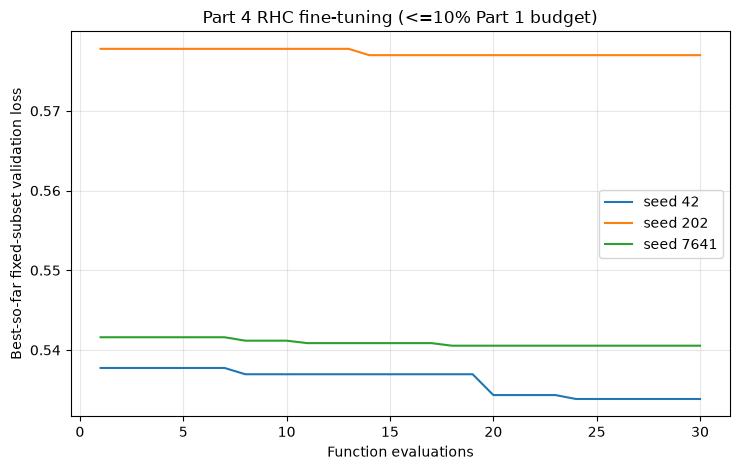

In [28]:
post_ro_runs, ro_progress_frames, post_rows = {}, [], []
for seed, trained in integrated_runs.items():
    model = CompactMLP(dropout=LOCKED_DROPOUT).to(DEVICE)
    load_state(model, trained["best_state"])
    params, trainable_count = freeze_for_ro(model, int(RO_CFG["final_linear_layers"]))
    assert trainable_count == int(RO_CFG["trainable_parameter_count"])
    x0 = vector_from_params(params)
    criterion = make_criterion(float(REG_CFG.get("label_smoothing", 0.0)))
    objective, calls = make_ro_objective(model, params, criterion)

    settings = dict(RO_CFG.get("settings", {}))
    if RO_CFG["algorithm"] == "GA":
        # Preserve GA mechanics while shrinking population so at least two generations fit.
        settings["population_size"] = min(int(settings.get("population_size", 20)), max(4, PART4_RO_BUDGET // 2))
        settings["elite_count"] = min(int(settings.get("elite_count", 2)), settings["population_size"] - 1)
    best_x, subset_loss, history, diagnostics = run_ro_algorithm(
        RO_CFG["algorithm"], objective, x0, PART4_RO_BUDGET, seed, settings
    )
    assert calls["count"] == PART4_RO_BUDGET
    vector_to_params(best_x, params)
    val_metrics, _ = evaluate_tensor(model, X_val_t, y_val_t, criterion)
    ro_time = float(history.wall_time_sec.iloc[-1])
    post_ro_runs[seed] = {
        "model": model, "seed": seed, "history": history,
        "config": trained["config"], "selected_val_metrics": val_metrics,
        "wall_time_sec": trained["wall_time_sec"] + ro_time,
        "gradient_evaluations": trained["gradient_evaluations"],
        "function_evaluations": PART4_RO_BUDGET,
        "trainable_parameter_count": trainable_count,
        "ro_wall_time_sec": ro_time,
    }
    hp = history.copy(); hp["seed"] = seed; ro_progress_frames.append(hp)
    post_rows.append({
        "stage": f"Integrated + {RO_CFG['algorithm']} RO", "seed": seed,
        "val_loss": val_metrics["loss"], "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "gradient_evaluations": trained["gradient_evaluations"],
        "function_evaluations": PART4_RO_BUDGET,
        "wall_time_sec": trained["wall_time_sec"] + ro_time,
    })
post_ro_summary = pd.DataFrame(post_rows)
combined_val_summary = pd.concat([integrated_val_summary, post_ro_summary], ignore_index=True)
combined_val_summary.to_csv(RESULTS_DIR / "integrated_validation_summary.csv", index=False)
display(combined_val_summary)

ro_progress = pd.concat(ro_progress_frames, ignore_index=True)
plt.figure(figsize=(7.5, 4.8))
for seed, g in ro_progress.groupby("seed"):
    plt.plot(g.function_evaluation, g.best_objective, label=f"seed {seed}")
plt.xlabel("Function evaluations")
plt.ylabel("Best-so-far fixed-subset validation loss")
plt.title(f"Part 4 {RO_CFG['algorithm']} fine-tuning (<=10% Part 1 budget)")
plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "integrated_ro_progress.png", dpi=160, bbox_inches="tight"); plt.show()

### 13. Final locked test evaluation and comparison

,method,seed,best_val_loss,best_val_macro_f1,test_accuracy,test_macro_f1,test_balanced_accuracy,wall_time_sec,gradient_evaluations,function_evaluations,notes
0,Integrated before RO,42,0.577985,0.599586,0.669102,0.585472,0.751813,5.559302,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
1,Integrated before RO,202,0.601154,0.556953,0.653362,0.558234,0.751223,5.318982,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
2,Integrated before RO,7641,0.573988,0.578986,0.650118,0.562555,0.744966,4.963271,1600,0,"{""batch_size"": 512, ""beta1"": 0.9, ""beta2"": 0.9..."
3,Integrated + RHC RO,42,0.578360,0.592598,0.662483,0.577007,0.752964,5.582223,1600,30,RO params=455; dropout=0.15000000000000002
4,Integrated + RHC RO,202,0.602392,0.555369,0.644829,0.557691,0.748916,5.349003,1600,30,RO params=455; dropout=0.15000000000000002
5,Integrated + RHC RO,7641,0.577171,0.580830,0.646765,0.563763,0.740535,4.986218,1600,30,RO params=455; dropout=0.15000000000000002


,source_part,method,median_test_accuracy,median_test_macro_f1,median_test_balanced_accuracy,median_wall_time_sec,median_gradient_evaluations,median_function_evaluations
6,ol_part2,Adam no bias correction,0.676460,0.582359,0.750074,3.969543,1600.0,0.0
13,ol_part3,Best single: L2 weight decay,0.659888,0.569672,0.745263,4.342379,1600.0,0.0
9,ol_part2,SGD momentum,0.664248,0.566574,0.741593,3.651207,1600.0,0.0
7,ol_part2,AdamW,0.682681,0.566124,0.753256,4.349254,1600.0,0.0
4,ol_part2,Adam,0.656366,0.565892,0.746417,4.319733,1600.0,0.0
11,ol_part3,Adam baseline,0.656366,0.565892,0.746417,4.332321,1600.0,0.0
5,ol_part2,Adam beta1=0,0.665742,0.564004,0.747706,4.244391,1600.0,0.0
14,ol_part4,Integrated + RHC RO,0.646765,0.563763,0.748916,5.349003,1600.0,30.0
15,ol_part4,Integrated before RO,0.653362,0.562555,0.751223,5.318982,1600.0,0.0
12,ol_part3,Best combination: wd+dropout,0.641115,0.547988,0.751433,4.866383,1600.0,0.0


,precision,recall,f1-score,support
Cover_Type_1,0.672391,0.734683,0.702158,204548.000000
Cover_Type_2,0.828617,0.545456,0.657860,273549.000000
Cover_Type_3,0.627519,0.703589,0.663380,34523.000000
Cover_Type_4,0.412873,0.793064,0.543038,2653.000000
Cover_Type_5,0.166611,0.817259,0.276793,9166.000000
Cover_Type_6,0.390464,0.662711,0.491400,16769.000000
Cover_Type_7,0.456462,0.926984,0.611709,19804.000000
accuracy,0.646765,0.646765,0.646765,0.646765
macro avg,0.507848,0.740535,0.563763,561012.000000
weighted avg,0.720265,0.646765,0.660978,561012.000000


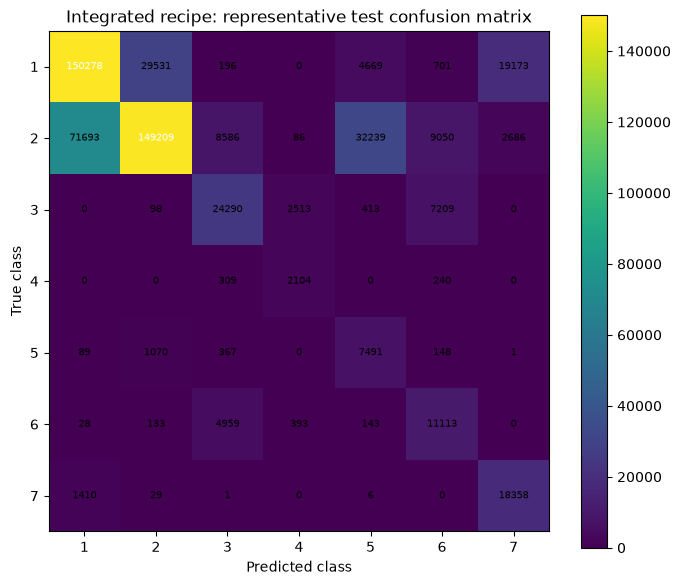

In [29]:
final_rows, reports, cms = [], {}, {}
if not SMOKE_TEST:
    for seed, run in integrated_runs.items():
        row, report, cm, _ = evaluate_test_locked(run, "Integrated before RO")
        final_rows.append(row); reports[("before", seed)] = report; cms[("before", seed)] = cm
    for seed, run in post_ro_runs.items():
        criterion = make_criterion(float(REG_CFG.get("label_smoothing", 0.0)))
        metrics, pred = evaluate_tensor(run["model"], X_test_t, y_test_t, criterion)
        report, cm = full_report(y_test, pred)
        final_rows.append({
            "method": f"Integrated + {RO_CFG['algorithm']} RO",
            "seed": seed,
            "best_val_loss": run["selected_val_metrics"]["loss"],
            "best_val_macro_f1": run["selected_val_metrics"]["macro_f1"],
            "test_accuracy": metrics["accuracy"],
            "test_macro_f1": metrics["macro_f1"],
            "test_balanced_accuracy": metrics["balanced_accuracy"],
            "wall_time_sec": run["wall_time_sec"],
            "gradient_evaluations": run["gradient_evaluations"],
            "function_evaluations": run["function_evaluations"],
            "notes": f"RO params={run['trainable_parameter_count']}; dropout={LOCKED_DROPOUT}",
        })
        reports[("after", seed)] = report; cms[("after", seed)] = cm

    final_metric_table = pd.DataFrame(final_rows)
    final_metric_table.to_csv(RESULTS_DIR / "final_metric_table.csv", index=False)
    display(final_metric_table)

    # Load prior final tables only for compact reporting; no configuration is changed from them here.
    prior_tables = []
    for part in ["ol_part1", "ol_part2", "ol_part3"]:
        p = Path("output_results") / part / "final_metric_table.csv"
        if p.exists():
            t = pd.read_csv(p); t["source_part"] = part; prior_tables.append(t)
    if prior_tables:
        all_methods = pd.concat(prior_tables + [final_metric_table.assign(source_part="ol_part4")], ignore_index=True)
        compact = all_methods.groupby(["source_part", "method"]).agg(
            median_test_accuracy=("test_accuracy", "median"),
            median_test_macro_f1=("test_macro_f1", "median"),
            median_test_balanced_accuracy=("test_balanced_accuracy", "median"),
            median_wall_time_sec=("wall_time_sec", "median"),
            median_gradient_evaluations=("gradient_evaluations", "median"),
            median_function_evaluations=("function_evaluations", "median"),
        ).reset_index().sort_values("median_test_macro_f1", ascending=False)
        compact.to_csv(RESULTS_DIR / "all_parts_compact_comparison.csv", index=False)
        display(compact)

    rep_seed = representative_seed(final_metric_table[final_metric_table.method.str.contains(r"Integrated \+")])
    reports[("after", rep_seed)].to_csv(RESULTS_DIR / "integrated_classification_report.csv")
    cms[("after", rep_seed)].to_csv(RESULTS_DIR / "integrated_confusion_matrix.csv")
    display(reports[("after", rep_seed)])
    plot_confusion_matrix(cms[("after", rep_seed)], "Integrated recipe: representative test confusion matrix",
                          FIG_DIR / "integrated_confusion_matrix.png")
else:
    print("Smoke test mode: final held-out test evaluation intentionally skipped.")

### 13.  Quantitative hypothesis resolution and practical decision rule

In [30]:
resolution = []

# H1-RO: use validation evidence available in this notebook even in smoke mode.
before_med = integrated_val_summary.val_macro_f1.median()
after_med = post_ro_summary.val_macro_f1.median()
ro_delta = after_med - before_med
if ro_delta > 0.005:
    ro_verdict = "accepted"
elif ro_delta > -0.002:
    ro_verdict = "qualified"
else:
    ro_verdict = "rejected"
resolution.append({"hypothesis": "RO provides only a marginal final-layer improvement",
                   "verdict": ro_verdict,
                   "evidence": f"median validation Macro-F1 delta after RO = {ro_delta:+.4f}; "
                               f"added FEs={PART4_RO_BUDGET}"})

# H2-OPT: load Part 2 stability table if present.
p2 = Path("output_results/ol_part2/optimizer_stability_summary.csv")
if p2.exists():
    opt = pd.read_csv(p2).set_index("condition")
    if "Adam" in opt.index and "SGD no momentum" in opt.index:
        adam_steps = opt.loc["Adam", "median_updates_to_threshold"]
        sgd_steps = opt.loc["SGD no momentum", "median_updates_to_threshold"]
        faster = pd.notna(adam_steps) and (pd.isna(sgd_steps) or adam_steps < sgd_steps)
        resolution.append({"hypothesis": "Adam reaches the validation-loss threshold faster than plain SGD",
                           "verdict": "accepted" if faster else "rejected",
                           "evidence": f"median updates to ell: Adam={adam_steps}, SGD={sgd_steps}"})

# H3-REG: load Part 3 final test table if present.
p3 = Path("output_results/ol_part3/final_metric_table.csv")
if p3.exists():
    reg = pd.read_csv(p3).groupby("method").median(numeric_only=True)
    if "Adam baseline" in reg.index:
        best_label = reg.test_macro_f1.idxmax()
        delta = reg.loc[best_label, "test_macro_f1"] - reg.loc["Adam baseline", "test_macro_f1"]
        resolution.append({"hypothesis": "Regularization materially improves class-balanced performance",
                           "verdict": "accepted" if delta > .005 else ("qualified" if delta > 0 else "rejected"),
                           "evidence": f"best test Macro-F1 delta vs Adam baseline = {delta:+.4f} ({best_label})"})

resolution_table = pd.DataFrame(resolution)
resolution_table.to_csv(RESULTS_DIR / "hypothesis_resolution.csv", index=False)
display(resolution_table)

print("Practical decision rule")
print("1. Use the Part 2 standard Adam setting when fast validation-loss reduction is required.")
print("2. Add the Part 3 regularization combination only when median Macro-F1/balanced accuracy improve across seeds and no rare class is materially harmed.")
print("3. Apply final-layer RO only when its full-validation gain survives seed aggregation; reject it when the gain is smaller than its function-evaluation and time cost.")
print("4. Prefer median/IQR and per-class recall/F1 over the single best seed or raw accuracy.")

save_json(RESULTS_DIR / "integrated_recipe.json", {
    "adam": ADAM_CFG,
    "regularization": {**REG_CFG, "locked_dropout_after_interaction_trials": LOCKED_DROPOUT},
    "ro": {**RO_CFG, "part4_function_evaluation_budget": PART4_RO_BUDGET},
    "seeds": SEEDS,
    "device": str(DEVICE),
    "data_paths": {"development": str(DATA_PATH), "test": str(DATA_PATH_TEST)},
})

,hypothesis,verdict,evidence
0,RO provides only a marginal final-layer improv...,qualified,median validation Macro-F1 delta after RO = +0...
1,Adam reaches the validation-loss threshold fas...,accepted,"median updates to ell: Adam=608.0, SGD=nan"
2,Regularization materially improves class-balan...,qualified,best test Macro-F1 delta vs Adam baseline = +0...


Practical decision rule
1. Use the Part 2 standard Adam setting when fast validation-loss reduction is required.
2. Add the Part 3 regularization combination only when median Macro-F1/balanced accuracy improve across seeds and no rare class is materially harmed.
3. Apply final-layer RO only when its full-validation gain survives seed aggregation; reject it when the gain is smaller than its function-evaluation and time cost.
4. Prefer median/IQR and per-class recall/F1 over the single best seed or raw accuracy.
